In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# If using Colab, ensure you have uploaded 'Merged_Nexus_Dataset.csv' to the files tab
df = pd.read_csv('Merged_Nexus_Dataset.csv')

# Convert timestamps and sort for time-series analysis
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['node_id', 'timestamp'])

# Filter for rows where the pump is actually running (Current > 0.5A) 
# to avoid skewed SEC values from idle energy
df_active = df[df['avgpf'] > 0.1].copy()

print(f"Dataset loaded with {df.shape[0]} records.")
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_19516\3100049892.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Merged_Nexus_Dataset.csv')


Dataset loaded with 1403819 records.


,slno,node_id,gwid,dtcname,tccode,meterno,realtimeclock,cumulativeenergykwhimport,phasecurrent,neutralcurrent,...,signalstrength,issid,time_key,timestamp,water_data,flowrate,rr_no,createddate,uniqueid_y,Dry_Run_Fault
1402233,55252942,NSRT000004,NSRT000004,NaN,NaN,02228878,2025-12-25 12:01:00,7122468.0,0.0,0.0,...,NaN,1752503,2025-12-25 12:00:00,2025-12-25 12:00:03,4749800.4,5.436,NWP6732,2026-01-14 13:06:11.140,1484962,0
1402619,55253118,NSRT000004,NSRT000004,NaN,NaN,02228878,2025-12-25 13:01:00,7123315.0,0.0,0.0,...,NaN,1753009,2025-12-25 13:00:00,2025-12-25 13:00:01,4750406.5,0.000,NWP6732,2026-01-14 13:06:11.140,1485937,0
1402398,55253004,NSRT000004,NSRT000004,NaN,NaN,02228878,2025-12-25 14:01:00,7123315.0,0.0,0.0,...,NaN,1752718,2025-12-25 14:00:00,2025-12-25 14:00:02,4750406.5,0.000,NWP6732,2026-01-14 13:06:11.140,1486903,0
1402306,55252978,NSRT000004,NSRT000004,NaN,NaN,02228878,2025-12-25 15:01:00,7123316.0,0.0,0.0,...,NaN,1752600,2025-12-25 15:00:00,2025-12-25 15:00:03,4750406.5,0.000,NWP6732,2026-01-14 13:06:11.140,1487890,0
1402538,55253030,NSRT000004,NSRT000004,NaN,NaN,02228878,2025-12-25 16:01:00,7123316.0,0.0,0.0,...,NaN,1752897,2025-12-25 16:00:00,2025-12-25 16:00:03,4750406.5,0.000,NWP6732,2026-01-14 13:06:11.140,1488836,0


In [2]:
# 1. Calculate Average Voltage across three phases
df_active['avg_voltage'] = df_active[['voltagerphase', 'voltageyphase', 'voltagebphase']].mean(axis=1)

# 2. Calculate Voltage Unbalance Factor (VUF)
# Formula: (Max Deviation from Avg / Avg Voltage) * 100
df_active['max_dev'] = df_active[['voltagerphase', 'voltageyphase', 'voltagebphase']].sub(df_active['avg_voltage'], axis=0).abs().max(axis=1)
df_active['vuf_percentage'] = (df_active['max_dev'] / df_active['avg_voltage']) * 100

# 3. Identify "Single Phasing" events (Dangerous for motors)
# Defined as one phase dropping below 50V while others are near 230V
df_active['is_single_phasing'] = ((df_active[['voltagerphase', 'voltageyphase', 'voltagebphase']] < 50).any(axis=1)) & \
                                 ((df_active[['voltagerphase', 'voltageyphase', 'voltagebphase']] > 180).any(axis=1))

print(f"Average Grid Imbalance (VUF): {df_active['vuf_percentage'].mean():.2f}%")
print(f"Critical Single-Phasing instances detected: {df_active['is_single_phasing'].sum()}")

Average Grid Imbalance (VUF): 5.44%
Critical Single-Phasing instances detected: 29439


In [3]:
# Calculate delta (change) in Energy and Water between readings
df_active['energy_delta_kwh'] = df_active.groupby('node_id')['cumulativeenergykwhimport'].diff()
df_active['water_delta_kl'] = df_active.groupby('node_id')['water_data'].diff()

# Calculate SEC (kWh / kL)
# We handle cases where water flow might be 0 to avoid infinity
df_active['SEC'] = df_active['energy_delta_kwh'] / df_active['water_delta_kl']

# Clean outliers (e.g., negative diffs or extreme spikes from sensor errors)
df_active = df_active[(df_active['SEC'] > 0) & (df_active['SEC'] < 5)] 

print(f"Median SEC for this grid: {df_active['SEC'].median():.4f} kWh/kL")

Median SEC for this grid: 1.5480 kWh/kL


In [4]:
# 1. Define the Baseline (The "Perfect Grid" Efficiency)
# We assume the pump is most efficient when voltage is between 225V and 235V
baseline_sec = df_active[(df_active['avg_voltage'] >= 225) & (df_active['avg_voltage'] <= 235)]['SEC'].median()

# 2. Calculate Excess Energy Waste
# Any SEC above baseline is considered waste caused by grid hostility
df_active['energy_waste_kwh'] = (df_active['SEC'] - baseline_sec) * df_active['water_delta_kl']
df_active['energy_waste_kwh'] = df_active['energy_waste_kwh'].clip(lower=0) # Only count losses

# 3. Calculate Financial Loss (Assuming 6.5 INR per kWh)
tariff = 6.50
df_active['loss_inr'] = df_active['energy_waste_kwh'] * tariff

total_loss = df_active['loss_inr'].sum()
total_water = df_active['water_delta_kl'].sum()

print(f"--- FINANCIAL AUDIT ---")
print(f"Estimated Baseline SEC: {baseline_sec:.4f} kWh/kL")
print(f"Total Money Wasted due to Grid Hostility: ₹{total_loss:.2f}")
print(f"Additional cost per kL delivered: ₹{(total_loss/total_water):.4f}")

--- FINANCIAL AUDIT ---
Estimated Baseline SEC: 1.6655 kWh/kL
Total Money Wasted due to Grid Hostility: ₹5127435434.77
Additional cost per kL delivered: ₹0.0821


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


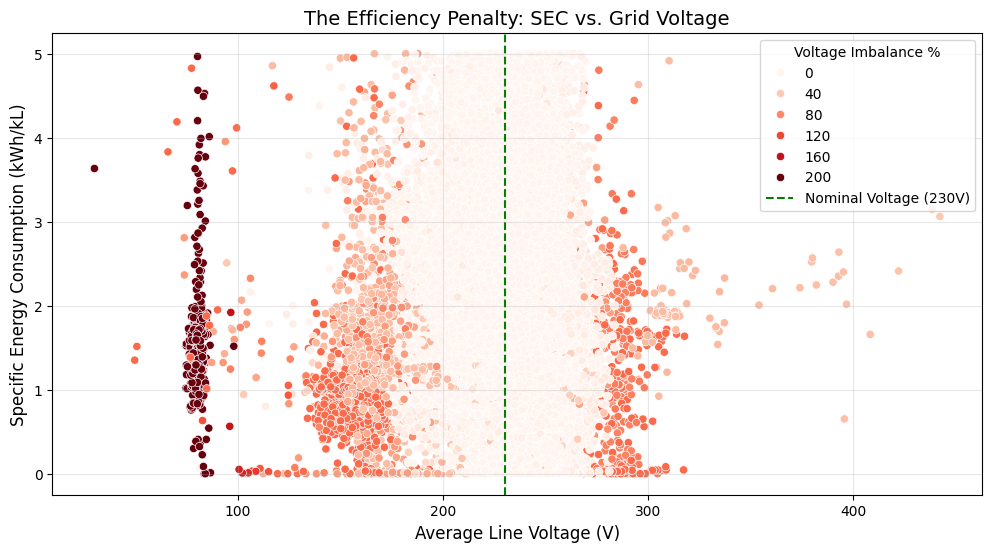

In [5]:
plt.figure(figsize=(12, 6))

# Plotting Voltage vs SEC
sns.scatterplot(data=df_active, x='avg_voltage', y='SEC', hue='vuf_percentage', palette='Reds')

plt.axvline(230, color='green', linestyle='--', label='Nominal Voltage (230V)')
plt.title('The Efficiency Penalty: SEC vs. Grid Voltage', fontsize=14)
plt.xlabel('Average Line Voltage (V)', fontsize=12)
plt.ylabel('Specific Energy Consumption (kWh/kL)', fontsize=12)
plt.legend(title='Voltage Imbalance %')
plt.grid(True, alpha=0.3)

plt.show()

In [6]:
# --- EXPORTING RESULTS TO CSV ---

# 1. Export the full processed dataset including all new columns (SEC, VUF, financial_loss)
audit_filename = 'Grid_Reliability_Audit_Full.csv'
df_active.to_csv(audit_filename, index=False)
print(f"Full audit data exported to: {audit_filename}")

# 2. Create and Export an Executive Summary Table(This groups the data by 'node_id' (each specific pump/location))
executive_summary = df_active.groupby('node_id').agg({
    'avg_voltage': 'mean',
    'vuf_percentage': 'mean',
    'is_single_phasing': 'sum',
    'water_delta_kl': 'sum',
    'energy_waste_kwh': 'sum',
    'loss_inr': 'sum'
}).reset_index()

# Rename columns for the final report
executive_summary.columns = [
    'Node_ID', 'Avg_Voltage_V', 'Avg_Imbalance_VUF', 
    'Single_Phase_Events', 'Total_Water_Pumped_kL', 
    'Total_Energy_Waste_kWh', 'Total_Financial_Loss_INR'
]

summary_filename = 'Grid_Lead_Executive_Summary.csv'
executive_summary.to_csv(summary_filename, index=False)

print(f"Executive summary exported to: {summary_filename}")

# Display the summary for a quick check
executive_summary.head()

Full audit data exported to: Grid_Reliability_Audit_Full.csv
Executive summary exported to: Grid_Lead_Executive_Summary.csv


,Node_ID,Avg_Voltage_V,Avg_Imbalance_VUF,Single_Phase_Events,Total_Water_Pumped_kL,Total_Energy_Waste_kWh,Total_Financial_Loss_INR
0,NSRT000004,243.398028,0.500304,0,1997911.9,332713.667097,2.162639e+06
1,NSRT000006,243.674000,0.408780,0,3257684.1,66494.832484,4.322164e+05
2,NSRT000007,240.212234,1.895198,0,4344957.5,0.000000,0.000000e+00
3,NSRT000010,232.801932,0.573095,0,1367432.5,24654.918823,1.602570e+05
4,NSRT000012,235.168620,0.905860,1,13516577.1,210.116087,1.365755e+03
